In [ ]:
!pip install scikit-learn


# **Random Forest Classifier Tutorial: How to Use Tree-Based Algorithms for Machine Learning**

Current document creation date: 28/01/2026

Article's publication date: 06/08/2020

By: Davis David

[Link to the article](https://www.freecodecamp.org/news/how-to-use-the-tree-based-algorithm-for-machine-learning/)

## **Data Set**

### Credit Card Fraud Detection

Data source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

```py
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
```




## **Evaluation Method**

> Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve ([AUPRC](https://share.google/aimode/Qhp6bwfRZNppsSCIF)). Confusion matrix accuracy is not meaningful for unbalanced classification.


## **How it works?**

The random forest algorithm works by completing the following steps:

* **Step 1:** The algorithm select random samples from the dataset provided.

* **Step 2:** The algorithm will create a decision tree for each sample selected. Then it will get a prediction result from each decision tree created.

* **Step 3:** Voting will then be performed for every predicted result. For a classification problem, it will use mode, and for a regression problem, it will use mean.

* **Step 4:** And finally, the algorithm will select the most voted prediction result as the final prediction.

The random forest algorithm can also help you to find features that are important in your dataset. It lies at the base of the [Boruta](https://towardsdatascience.com/boruta-explained-the-way-i-wish-someone-explained-it-to-me-4489d70e154a) algorithm, which selects important features in a dataset.

![Random Forest Classifier](https://www.freecodecamp.org/news/content/images/2020/08/how-random-forest-classifier-work.PNG)

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler


from matplotlib import rcParams
import warnings

warnings.filterwarnings("ignore")

# figure size in inches
rcParams["figure.figsize"] = 10, 6


path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print(path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
/kaggle/input/creditcardfraud


In [ ]:
df = pd.read_csv(path+'/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## **Cleaning the Dataset**

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

**[Why scale?](https://towardsdatascience.com/how-and-why-to-standardize-your-data-996926c2c832/)**

> Variables that are measured at different scales do not contribute equally to the model fitting & model learned function and might end up creating a bias.



In [ ]:
# standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled.mean(axis=0)

array([-3.06563713e-16, -1.50687242e-17, -9.58011603e-18, -8.62210442e-17,
       -5.18922951e-18,  3.83204641e-17,  9.97928753e-18,  1.23743165e-17,
       -3.19337201e-18,  7.23498346e-19,  5.58840102e-18, -4.31105221e-17,
        1.67652030e-17, -1.25240058e-17,  2.59461476e-17, -2.07569181e-17,
        1.83618891e-17,  3.39295776e-18,  2.63453191e-17,  4.36593829e-18,
       -1.24741094e-18, -3.64243995e-18,  3.19337201e-18,  8.78177302e-18,
        9.58011603e-18, -5.02956091e-17,  5.88777964e-18,  2.44492544e-18,
       -7.90858537e-18,  2.91395196e-17])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, stratify=y, test_size=0.10, random_state=42
)

## **Training the classifier**

In [ ]:
classifier = RandomForestClassifier(n_estimators=100) # estimators = number of trees built
classifier.fit(X_train, y_train)

RandomForestClassifier()

## **Predicting with the classifier**

In [ ]:
y_pred = classifier.predict(X_test)

## **Calculating accuracy**

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9995786664794073


## **Feature importance**

In this section, feature importances is displayed in order to get a graphical understanding of the impact from our inputs to the model.

In [ ]:
feature_importances_df = pd.DataFrame({
    'feature_list': list(X.columns),
    'importance': classifier.feature_importances_
}).sort_values('importance', ascending=False)

feature_importances_df


,feature_list,importance
17,V17,0.195156
12,V12,0.114786
14,V14,0.114648
10,V10,0.082785
16,V16,0.069017
11,V11,0.055890
9,V9,0.038925
18,V18,0.036123
4,V4,0.026557
7,V7,0.021338


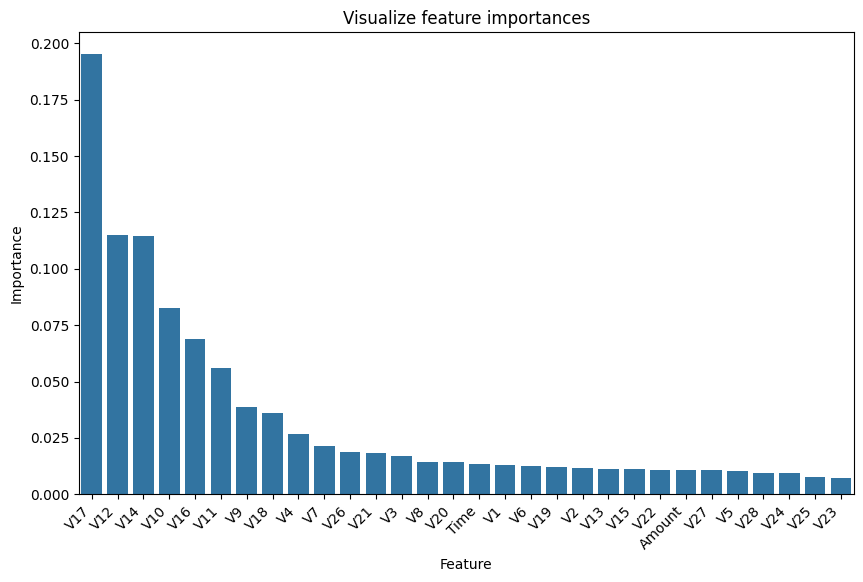

In [ ]:
# Creating a bar plot with sns
sns.barplot(x=feature_importances_df.feature_list, y=feature_importances_df.importance)

# Labeling the axis and title
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Visualize feature importances')
plt.xticks(
    rotation=45, horizontalalignment='right', fontsize="medium"
)

plt.show()

## **Remove Feature V23**

We'll remove feature V23 since it is our least important one and see if the model improves.

Remeber, our last accuracy score was: 0.9995786664794073

In [ ]:
X_2 = df.drop(['Class', 'V23'], axis=1)
y_2 = df['Class']

X_scaled_2 = scaler.fit_transform(X_2)

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_scaled_2, y_2, stratify=y_2, test_size=0.10, random_state=42
)

clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train_2, y_train_2)

y_pred_2 = clf.predict(X_test_2)

print("Accuracy:", accuracy_score(y_test_2, y_pred_2))


Accuracy: 0.9996137776061234


In [ ]:
from sklearn.metrics import PrecisionRecallDisplay


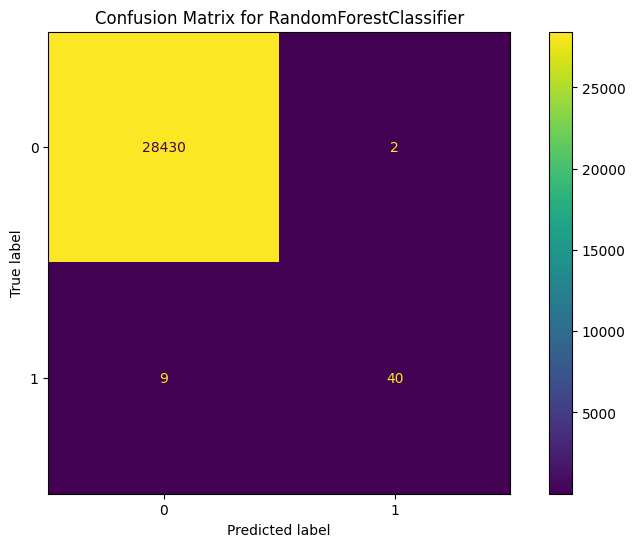

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
cm = confusion_matrix(y_test_2, y_pred_2)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.title('Confusion Matrix for RandomForestClassifier')
plt.show()

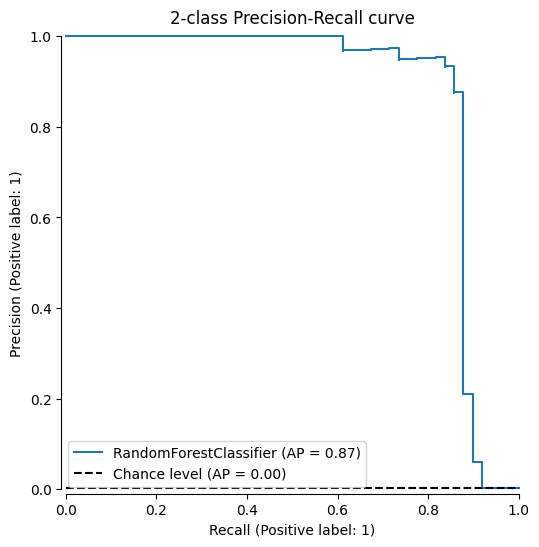

In [ ]:
y_score = clf.predict_proba(X_test_2)[:,1]

display = PrecisionRecallDisplay.from_predictions(
    y_test, y_score, name="RandomForestClassifier", plot_chance_level=True, despine=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [ ]:
y_pred_2.sum()

np.int64(42)